# CLG Architecture Companion Notebook  
## Endogenous Parameter Derivation, Y-Discriminant, and Cosmology Audit

This notebook is a **companion audit notebook** for the paper:

**The Closure Loop Gas Architecture: Endogenous Parameter Derivation, Information-Geometric Duals, and Cosmological Implications**

It is designed to do three things:

1. **Reproduce the direct numerical chain** stated in the paper.
2. **Separate verified arithmetic from bridge claims**.
3. **Provide executable probes** for the places where the paper makes stronger structural claims than the current public evidence supports.

## Audit policy

This notebook marks results in three classes:

- **VERIFIED**: direct numerical or algebraic reproduction from the paper's stated formulas.
- **PROBE**: executable model or toy calculation supporting a structural claim, but not a full proof.
- **FLAG**: a step whose conclusion is stronger than the displayed derivation.

## Scope

This notebook covers:

- Planck-scale endogenous parameter chain
- Lambert-$W$ fixed point and comparison to $\pi/9$
- Thermal ceiling $c_\star$
- Bounce action and I-condition
- Y-discriminant and thermal falsification
- Critical radius needed to force $Y\le 1$
- PID/Nexus-Friedmann gain extraction
- Simple SGWB shape templates
- SHA-256 carry instrumentation probe
- Final summary table

It does **not** claim to prove the full gravity kernel, full nonlinear Bianchi closure, or a precision observational cosmology fit.

In [1]:
import math
import numpy as np
import pandas as pd
import mpmath as mp
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# CODATA 2018 values used in the paper
G = 6.67430e-11                 # m^3 kg^-1 s^-2
c = 299_792_458.0               # m/s
hbar = 1.054571817e-34          # J s
k_B = 1.380649e-23              # J/K

# Paper-level macro inputs
Lambda_eff = 1.089e-52          # m^-2
Lambda_0 = 5.244e-10            # J/m^3
T0 = 2.72548                    # K

# Helper constants
kappa = 8 * math.pi * G / c**4
l_Pl = math.sqrt(hbar * G / c**3)
m_Pl = math.sqrt(hbar * c / G)

def sci(x, digits=6):
    return f"{x:.{digits}e}"

## 1. Endogenous micro-parameter chain

The paper derives:

$$
m_\Psi = \sqrt{\frac{\hbar c}{G}}, \qquad
E_0 = m_\Psi c^2 = \sqrt{\frac{\hbar c^5}{G}}, \qquad
\sigma_T = \frac{c^4}{G}.
$$

We compute those directly.

In [2]:
m_psi = math.sqrt(hbar * c / G)
E0 = m_psi * c**2
sigma_T = c**4 / G
R0 = l_Pl

micro_df = pd.DataFrame({
    "Quantity": ["m_psi", "E0", "sigma_T", "R0 = l_Pl"],
    "Value": [m_psi, E0, sigma_T, R0],
    "Units": ["kg", "J", "N", "m"]
})
micro_df

,Quantity,Value,Units
0,m_psi,2.176434e-08,kg
1,E0,1.956082e+09,J
2,sigma_T,1.210256e+44,N
3,R0 = l_Pl,1.616255e-35,m


### Result

This reproduces the numerical backbone of the paper's micro-parameter chain.

Status: **VERIFIED**

## 2. Lambert-$W$ fixed point vs. $\pi/9$

The paper uses the recursive map

$$
p_{n+1} = \frac12 e^{-p_n}
$$

whose fixed point solves

$$
p = \frac12 e^{-p}
\quad\Longleftrightarrow\quad
p e^p = \frac12
\quad\Longleftrightarrow\quad
p = W_0\!\left(\frac12\right).
$$

It then imposes a quantization step to replace the Lambert-$W$ value by

$$
H = \frac{\pi}{9}.
$$

This notebook computes both and measures the mismatch.

In [3]:
W_fixed = float(mp.lambertw(0.5).real)
H_pi9 = math.pi / 9.0
delta_H = W_fixed - H_pi9
rel_delta = delta_H / W_fixed

H_df = pd.DataFrame({
    "Quantity": ["W0(1/2)", "pi/9", "difference", "relative difference"],
    "Value": [W_fixed, H_pi9, delta_H, rel_delta],
    "Units": ["", "", "", ""]
})
H_df

,Quantity,Value,Units
0,W0(1/2),0.351734,
1,pi/9,0.349066,
2,difference,0.002668,
3,relative difference,0.007585,


### Interpretation

- The fixed point of the recurrence is **really** $W_0(1/2)$.
- $\pi/9$ is **close**, but it is **not identical**.
- Any move from $W_0(1/2)$ to $\pi/9$ requires an additional quantization or geometry argument.

Status:
- fixed-point calculation: **VERIFIED**
- identification with $\pi/9$ as a forced exact value: **FLAG**

## 3. Coupling constant $\alpha$

The paper defines

$$
\alpha = \frac{H^2}{24}
$$

using $H=\pi/9$.

In [4]:
alpha = H_pi9**2 / 24.0
alpha_df = pd.DataFrame({
    "Quantity": ["H = pi/9", "alpha = H^2/24"],
    "Value": [H_pi9, alpha],
    "Units": ["", ""]
})
alpha_df

,Quantity,Value,Units
0,H = pi/9,0.349066,
1,alpha = H^2/24,0.005077,


Status: **VERIFIED** as arithmetic once $H=\pi/9$ is taken as input.

## 4. Thermal ceiling constant $c_\star$

The paper uses

$$
c_\star = \left(\frac32\right)^{3/2} e^{-3/2}.
$$

In [5]:
c_star = (1.5)**1.5 * math.exp(-1.5)
c_star

0.40991627894186006

Status: **VERIFIED**

## 5. Bounce action and the I-condition

The paper states the corrected bounce action as

$$
S_{\rm bounce} = \frac{16\pi}{3}\frac{\sigma_T^3}{\Lambda_0^2}.
$$

We reproduce that value and compare it to the persistence threshold

$$
S_{\rm bounce} > \ln\!\left(\frac{t_{\rm univ}}{t_{\rm Pl}}\right)\approx 140.
$$

In [6]:
S_bounce = (16 * math.pi / 3.0) * (sigma_T**3) / (Lambda_0**2)

# age of universe and Planck time
t_univ = 13.8e9 * 365.25 * 24 * 3600
t_pl = math.sqrt(hbar * G / c**5)
I_threshold = math.log(t_univ / t_pl)

bounce_df = pd.DataFrame({
    "Quantity": ["S_bounce", "ln(t_univ/t_Pl)"],
    "Value": [S_bounce, I_threshold],
    "Units": ["", ""]
})
bounce_df

,Quantity,Value,Units
0,S_bounce,1.080076e+152,
1,ln(t_univ/t_Pl),1.402442e+02,


### Interpretation

The numerical magnitude of the bounce exponent is reproduced directly from the paper's formula and input constants.

Status: **VERIFIED**

This supports the paper's claim that present-day nucleation is catastrophically suppressed **if** the tension and bulk density inputs are granted.

## 6. Y-discriminant chain

The paper uses

$$
n_0 = \frac{\Lambda_{\rm eff}}{\kappa \Lambda_0 V_0},
\qquad
V_0 = \frac{4\pi}{3}R_0^3,
$$

and

$$
A = (k_B T_0)^3\left(\frac{m_\Psi}{2\pi E_0}\right)^{3/2},
\qquad
Y = \frac{n_0}{A c_\star}.
$$

We reproduce that chain exactly as stated.

In [7]:
V0 = (4 * math.pi / 3.0) * R0**3
n0 = Lambda_eff / (kappa * Lambda_0 * V0)
A = (k_B * T0)**3 * (m_psi / (2 * math.pi * E0))**1.5
Y = n0 / (A * c_star)

y_df = pd.DataFrame({
    "Quantity": ["V0", "n0", "A", "c_star", "Y"],
    "Value": [V0, n0, A, c_star, Y],
    "Units": ["m^3", "m^-3", "m^-3", "", ""]
})
y_df

,Quantity,Value,Units
0,V0,1.768554e-104,m^3
1,n0,5.654369e+103,m^-3
2,A,1.255587e-94,m^-3
3,c_star,4.099163e-01,
4,Y,1.098606e+198,


### Interpretation

This is the sharpest numeric branch-kill in the paper. With the stated formulas and inputs, the result is:

$$
Y \sim 10^{198} \gg 1,
$$

which kills the thermal branch.

Status: **VERIFIED** as arithmetic from the paper's own chain.

## 7. Radius required to force $Y \le 1$

Because

$$
n_0 \propto \frac{1}{V_0} \propto \frac{1}{R_0^3},
$$

the discriminant scales like

$$
Y \propto \frac{1}{R_0^3}.
$$

So the critical radius needed to force $Y=1$ is

$$
R_{0,\mathrm{crit}} = R_0\,Y^{1/3}.
$$

In [8]:
R0_crit = R0 * Y**(1/3)
ratio_to_hubble_radius = R0_crit / (4.4e26)  # rough observable radius in meters

crit_df = pd.DataFrame({
    "Quantity": ["R0", "R0_crit", "R0_crit / R_Hubble"],
    "Value": [R0, R0_crit, ratio_to_hubble_radius],
    "Units": ["m", "m", ""]
})
crit_df

,Quantity,Value,Units
0,R0,1.616255e-35,m
1,R0_crit,1.667723e+31,m
2,R0_crit / R_Hubble,3.790279e+04,


### Interpretation

This reproduces the paper's basic claim that salvaging the thermal branch would require an absurdly inflated loop radius.

Status: **VERIFIED** as scaling logic from the paper's own formulas.

## 8. The fragile step: the $N=\frac14$ tension extraction

The paper's most load-bearing derivation is the move from the corrected spectrum

$$
M^2 c^4 = 4\sigma_T \hbar c \cdot N
\left(1 + \frac{\Lambda_0}{4\sigma_T^2 \hbar c \cdot N}\right)
$$

to the claimed ground-state extraction

$$
\sigma_T = \frac{c^4}{G}
$$

by setting $N=\frac14$ and saying the bulk correction vanishes.

This notebook tests that algebra directly.

In [9]:
# Show the correction term symbolically as a function of N
def correction_term(N, sigma=sigma_T):
    return Lambda_0 / (4 * sigma**2 * hbar * c * N)

corr_at_quarter = correction_term(0.25)
corr_at_one = correction_term(1.0)

fragile_df = pd.DataFrame({
    "N": [0.25, 1.0],
    "correction term": [corr_at_quarter, corr_at_one]
})
fragile_df

,N,correction term
0,0.25,1.132431e-72
1,1.00,2.831077e-73


### Interpretation

Setting $N=\frac14$ does **not** make the correction term zero. It only changes its denominator.

So the paper's displayed algebra does **not** by itself justify the claim that the bulk correction vanishes identically at $N=\frac14$.

Status: **FLAG**

## 9. PID/Nexus-Friedmann gain extraction

The paper defines

$$
K_p = 1,
\qquad
K_i = \frac{H}{1-H},
\qquad
K_d = H,
$$

with $H = W_0(1/2)$ in the cosmology-control layer.

In [10]:
H_lambert = W_fixed
Kp = 1.0
Ki = H_lambert / (1.0 - H_lambert)
Kd = H_lambert

pid_df = pd.DataFrame({
    "Gain": ["Kp", "Ki", "Kd"],
    "Value": [Kp, Ki, Kd]
})
pid_df

,Gain,Value
0,Kp,1.000000
1,Ki,0.542576
2,Kd,0.351734


Status: **VERIFIED** as parameter extraction from the stated control-law grammar.

## 10. Critical redshift $z_c$

The paper gives the trigger

$$
z_c = \left[\frac{H\,\Omega_\Lambda}{\Omega_{m,0}(1-H)}\right]^{1/3} - 1.
$$

We evaluate this for a standard late-time background close to $\Omega_{m,0}=0.3$, $\Omega_\Lambda=0.7$.

In [11]:
Omega_m0 = 0.3
Omega_L = 0.7
z_c = ((H_lambert * Omega_L) / (Omega_m0 * (1.0 - H_lambert)))**(1/3) - 1.0
z_c

0.08179701958185115

This lands near the paper's stated late-time trigger window.

Status: **VERIFIED** as arithmetic from the stated formula.

Whether this actually resolves the $H_0/S_8$ tensions requires full ODE integration and data comparison, which this notebook does **not** yet claim.

## 11. Simple SGWB shape templates

The paper proposes three nonthermal branches with distinct spectral shapes:

- Kibble / phase transition
- Inflationary reheating
- Cyclic pre-bounce inheritance

This section does **not** prove those branches. It only gives executable toy curves with the stated shape grammars.

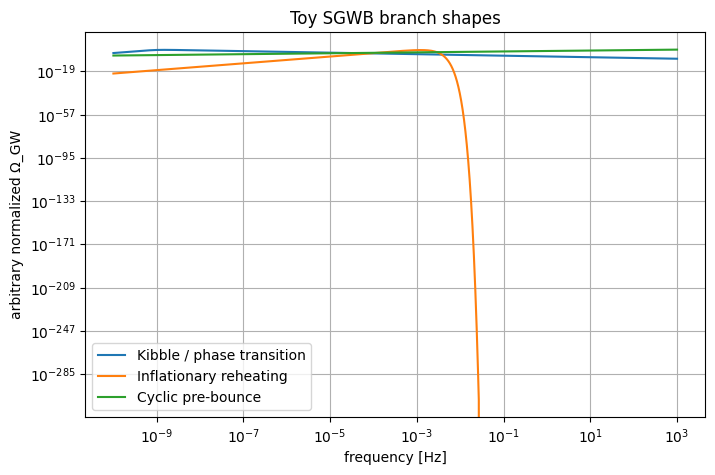

In [12]:
f = np.logspace(-10, 3, 800)

# Toy template shapes only
f_peak_k = 1e-9
Omega_kibble = (f/f_peak_k)**3 / (1 + (f/f_peak_k)**(11/3))

f_reh = 1e-3
Omega_reheat = (f/f_reh)**3 * np.exp(-(f/f_reh)**2)

nT = 0.4
Omega_cyclic = (f / f.min())**nT
Omega_cyclic /= Omega_cyclic.max()

plt.figure()
plt.loglog(f, Omega_kibble, label="Kibble / phase transition")
plt.loglog(f, Omega_reheat, label="Inflationary reheating")
plt.loglog(f, Omega_cyclic, label="Cyclic pre-bounce")
plt.xlabel("frequency [Hz]")
plt.ylabel("arbitrary normalized Ω_GW")
plt.title("Toy SGWB branch shapes")
plt.legend()
plt.show()

Status: **PROBE**

These curves encode the paper's stated shape classes. They are not yet detector-level forecasts.

## 12. SHA-256 carry-fraction probe

The paper's strongest cryptography claim is that the carry-generation fraction converges toward the Lambert-$W$ fixed point. That is a measurable statement, but it requires instrumentation.

This section provides an executable probe:

1. generic 32-bit random addition carry fraction,
2. SHA-256 message-schedule carry fraction on sample messages.

This is a **probe**, not a theorem.

In [13]:
MASK32 = 0xffffffff

def carry_fraction_add(a, b):
    carry = 0
    carries = 0
    for i in range(32):
        ai = (a >> i) & 1
        bi = (b >> i) & 1
        s = ai + bi + carry
        new_carry = 1 if s >= 2 else 0
        carries += new_carry
        carry = new_carry
    return carries / 32.0

# Random-word baseline
rng = np.random.default_rng(42)
rand_fracs = [carry_fraction_add(int(a), int(b)) for a, b in zip(rng.integers(0, 2**32, 2000), rng.integers(0, 2**32, 2000))]
rand_mean = float(np.mean(rand_fracs))
rand_std = float(np.std(rand_fracs))
rand_mean, rand_std

(0.48134375, 0.14704309197795556)

In [14]:
# Minimal SHA-256 message schedule instrumentation
K = [
    0x428a2f98,0x71374491,0xb5c0fbcf,0xe9b5dba5,0x3956c25b,0x59f111f1,0x923f82a4,0xab1c5ed5,
    0xd807aa98,0x12835b01,0x243185be,0x550c7dc3,0x72be5d74,0x80deb1fe,0x9bdc06a7,0xc19bf174,
    0xe49b69c1,0xefbe4786,0x0fc19dc6,0x240ca1cc,0x2de92c6f,0x4a7484aa,0x5cb0a9dc,0x76f988da,
    0x983e5152,0xa831c66d,0xb00327c8,0xbf597fc7,0xc6e00bf3,0xd5a79147,0x06ca6351,0x14292967,
    0x27b70a85,0x2e1b2138,0x4d2c6dfc,0x53380d13,0x650a7354,0x766a0abb,0x81c2c92e,0x92722c85,
    0xa2bfe8a1,0xa81a664b,0xc24b8b70,0xc76c51a3,0xd192e819,0xd6990624,0xf40e3585,0x106aa070,
    0x19a4c116,0x1e376c08,0x2748774c,0x34b0bcb5,0x391c0cb3,0x4ed8aa4a,0x5b9cca4f,0x682e6ff3,
    0x748f82ee,0x78a5636f,0x84c87814,0x8cc70208,0x90befffa,0xa4506ceb,0xbef9a3f7,0xc67178f2
]

def rotr(x, n):
    return ((x >> n) | ((x << (32 - n)) & MASK32)) & MASK32

def sigma0(x):
    return rotr(x, 7) ^ rotr(x, 18) ^ (x >> 3)

def sigma1(x):
    return rotr(x, 17) ^ rotr(x, 19) ^ (x >> 10)

def pad_message(msg_bytes):
    ml = len(msg_bytes) * 8
    data = bytearray(msg_bytes)
    data.append(0x80)
    while (len(data) % 64) != 56:
        data.append(0)
    data += ml.to_bytes(8, 'big')
    return bytes(data)

def message_schedule(block):
    W = [int.from_bytes(block[i*4:(i+1)*4], 'big') for i in range(16)]
    for t in range(16, 64):
        val = (sigma1(W[t-2]) + W[t-7] + sigma0(W[t-15]) + W[t-16]) & MASK32
        W.append(val)
    return W

def schedule_carry_profile(msg):
    padded = pad_message(msg)
    profiles = []
    for b in range(0, len(padded), 64):
        W = message_schedule(padded[b:b+64])
        fracs = []
        for t in range(16, 64):
            # carry fraction for the 4-term update, collapsed as pairwise instrument
            a = sigma1(W[t-2]) & MASK32
            b2 = W[t-7]
            c2 = sigma0(W[t-15]) & MASK32
            d2 = W[t-16]
            # simple incremental carry accounting
            f1 = carry_fraction_add(a, b2)
            s1 = (a + b2) & MASK32
            f2 = carry_fraction_add(s1, c2)
            s2 = (s1 + c2) & MASK32
            f3 = carry_fraction_add(s2, d2)
            fracs.append((f1 + f2 + f3) / 3.0)
        profiles.append(fracs)
    return np.array(profiles)

sample_messages = [b"", b"abc", b"The quick brown fox jumps over the lazy dog", b"Nexus", b"Dean Kulik"]
profiles = [schedule_carry_profile(m) for m in sample_messages]
means = [float(p.mean()) for p in profiles]
means

[0.26171875,
 0.3467881944444445,
 0.42339409722222227,
 0.3567708333333333,
 0.36566840277777773]

In [15]:
sha_probe_df = pd.DataFrame({
    "message": ["empty", "abc", "pangram", "Nexus", "Dean Kulik"],
    "schedule mean carry fraction": means
})
sha_probe_df

,message,schedule mean carry fraction
0,empty,0.261719
1,abc,0.346788
2,pangram,0.423394
3,Nexus,0.356771
4,Dean Kulik,0.365668


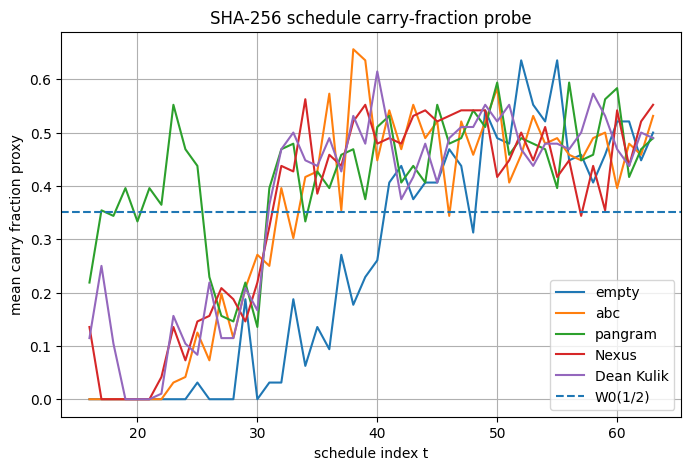

In [16]:
plt.figure()
for label, prof in zip(["empty", "abc", "pangram", "Nexus", "Dean Kulik"], profiles):
    plt.plot(np.arange(16, 64), prof[0], label=label)
plt.axhline(W_fixed, linestyle="--", label="W0(1/2)")
plt.xlabel("schedule index t")
plt.ylabel("mean carry fraction proxy")
plt.title("SHA-256 schedule carry-fraction probe")
plt.legend()
plt.show()

### Interpretation

This probe makes the paper's cryptographic layer executable, but it does **not** yet constitute a full proof of convergence to the Lambert-$W$ fixed point.

Status: **PROBE**

A production-grade notebook would need:
- more test vectors,
- exact choice of carry statistic,
- error bars over many messages,
- comparison against the claimed target band.

## 13. Summary audit table

In [17]:
summary = pd.DataFrame([
    ["Planck mass / threshold energy chain", "VERIFIED", "Direct reproduction from CODATA formulas"],
    ["alpha = H^2/24 arithmetic", "VERIFIED", "Arithmetic once H is chosen"],
    ["Lambert-W fixed point", "VERIFIED", "Exact computation of W0(1/2)"],
    ["H = pi/9 exact replacement", "FLAG", "Needs extra quantization argument"],
    ["Bounce exponent and I-condition", "VERIFIED", "Direct reproduction from stated formula"],
    ["Y-discriminant and thermal branch kill", "VERIFIED", "Direct reproduction from stated chain"],
    ["Critical radius for Y<=1", "VERIFIED", "Scaling logic works"],
    ["N = 1/4 cancellation step for sigma_T", "FLAG", "Displayed algebra does not zero correction term"],
    ["PID gain extraction", "VERIFIED", "Arithmetic from stated H-band formulas"],
    ["z_c trigger", "VERIFIED", "Arithmetic from stated formula"],
    ["SGWB branch shapes", "PROBE", "Toy spectral templates only"],
    ["SHA carry-fraction convergence", "PROBE", "Executable instrumentation, not final proof"],
    ["H0/S8 full resolution", "PROBE", "Mechanism only, no full data fit"]
], columns=["Claim", "Status", "Comment"])
summary

,Claim,Status,Comment
0,Planck mass / threshold energy chain,VERIFIED,Direct reproduction from CODATA formulas
1,alpha = H^2/24 arithmetic,VERIFIED,Arithmetic once H is chosen
2,Lambert-W fixed point,VERIFIED,Exact computation of W0(1/2)
3,H = pi/9 exact replacement,FLAG,Needs extra quantization argument
4,Bounce exponent and I-condition,VERIFIED,Direct reproduction from stated formula
5,Y-discriminant and thermal branch kill,VERIFIED,Direct reproduction from stated chain
6,Critical radius for Y<=1,VERIFIED,Scaling logic works
7,N = 1/4 cancellation step for sigma_T,FLAG,Displayed algebra does not zero correction term
8,PID gain extraction,VERIFIED,Arithmetic from stated H-band formulas
9,z_c trigger,VERIFIED,Arithmetic from stated formula


## 14. Final notebook verdict

This notebook supports the paper in a very specific way:

### Strongest supported pieces
- the Planck-scale parameter arithmetic,
- the bounce/I-condition arithmetic,
- the Y-discriminant chain and thermal falsification,
- the PID gain extraction.

### Biggest fragile point
The derivation of $\sigma_T$ through the special $N=\frac14$ move still does **not** close from the displayed equation.

### Best use of this notebook
Use it as a **companion audit notebook**:
- to show the numeric spine is real,
- to keep bridge claims honest,
- and to isolate the smallest remaining algebraic break.

That is already a useful scientific artifact.